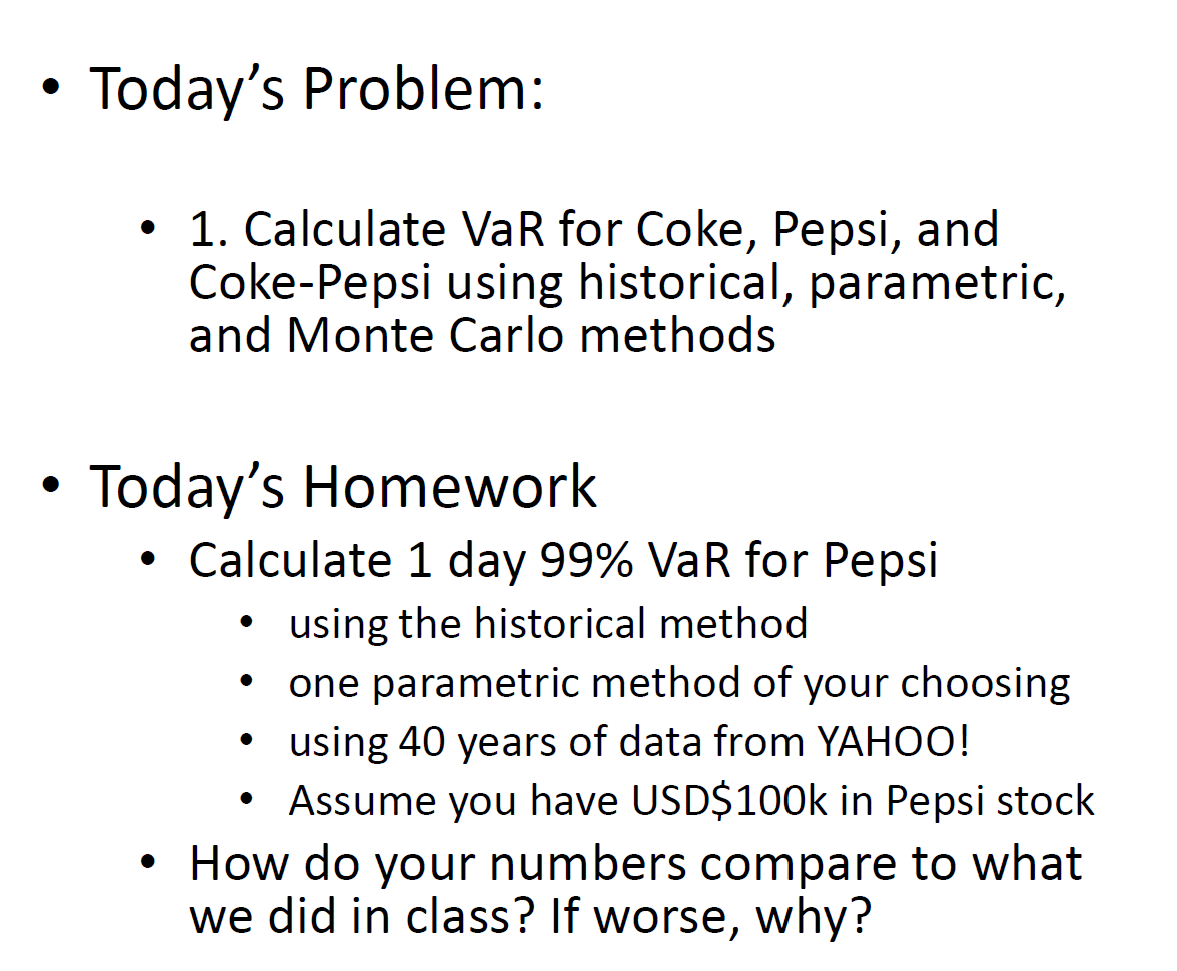

In [62]:
import pandas as pd
import yfinance as yf
import numpy as np
from math import prod
from scipy.stats import norm
import random
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import normal_ad
from datetime import date
from dateutil.relativedelta import relativedelta
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.linear_model import LinearRegression
import math
from scipy.stats import t
from scipy.stats import norm
from scipy.stats import genextreme

In [18]:
n_year = 1
n_month = 12
n_day = 252
princeple = 100000

### 1. Pull one year daily price data
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=40)
tickers = ["KO", "PEP"]

raw = yf.download(tickers, start=start, end=end, auto_adjust=False,progress=False)
prices = raw["Adj Close"].copy()
KO_current_price = prices['KO'][-1] ### Current price of KO
pep_current_price = prices['PEP'][-1] ### Current price of PEP

C:\Users\w28sh\AppData\Local\Temp\ipykernel_19404\1827779485.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  KO_current_price = prices['KO'][-1] ### Current price of KO
C:\Users\w28sh\AppData\Local\Temp\ipykernel_19404\1827779485.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pep_current_price = prices['PEP'][-1] ### Current price of PEP


### 1. Historical Method

In [19]:
diff_price = prices.diff()
diff_price.columns = ['KO_diff','PEP_diff']
prices = prices.merge(diff_price, left_index=True, right_index=True).dropna()
prices['r_KO'] = prices['KO_diff']/prices['KO']
prices['r_PEP'] = prices['PEP_diff']/prices['PEP']

In [26]:
hVar_99_percent  = np.percentile(prices['r_PEP'], [1])
hVar_99_dollar_loss = hVar_99[0]*princeple
hVar_99_percent, hVar_99_dollar_loss

(array([-0.04077507]), np.float64(-4077.5073594387814))

20


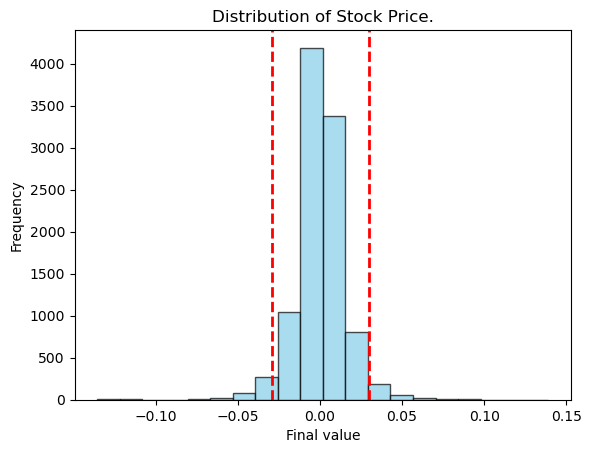

In [37]:
n_bins = 20 #int(1 + np.log2(len( prices['r_PEP'] )))
print(n_bins)

plt.hist(prices['r_PEP'] , bins=n_bins, color='skyblue', edgecolor='black', alpha=0.7)

lower_CI = np.mean(prices['r_PEP']) - 1.96 * np.std(prices['r_PEP'])
upper_CI = np.mean(prices['r_PEP']) + 1.96 * np.std(prices['r_PEP'])

plt.axvline(x=lower_CI, color='red', linestyle='--', linewidth=2, label='Mean - 1.96·STD (95%CI)')
plt.axvline(x=upper_CI, color='red', linestyle='--', linewidth=2, label='Mean + 1.96·STD (95%CI)')

plt.title(f'Distribution of Stock Price.')
plt.xlabel('Final value')
plt.ylabel('Frequency')
plt.show()

In [97]:
print('Historical method 99% Var = :', hVar_99_dollar_loss)

Historical method 99% Var = : -4077.5073594387814


### 2. Parametric Method
From above distribution, the fat tail looks like the distribution is t distribution, which also aligned with below result.

In [78]:
data = 1+prices['r_PEP']
results = []

# Normal
mu_norm, sigma_norm = stats.norm.fit(data)
results.append({
    "dist": "Normal",
    "params": (mu_norm, sigma_norm)
})

# Lognormal
shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(data, floc=0)  
results.append({
    "dist": "Lognormal",
    "params": (shape_lognorm, loc_lognorm, scale_lognorm)
})

# Student-t
df_t, loc_t, scale_t = stats.t.fit(data)
results.append({
    "dist": "Student-t",
    "params": (df_t, loc_t, scale_t)
})

# Logistic
loc_logistic, scale_logistic = stats.logistic.fit(data)
results.append({
    "dist": "Logistic",
    "params": (loc_logistic, scale_logistic)
})

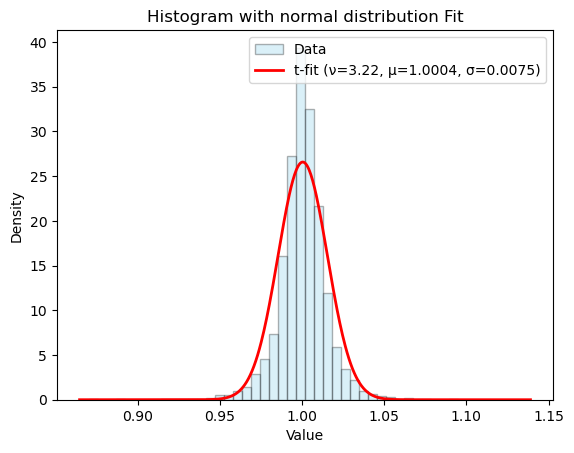

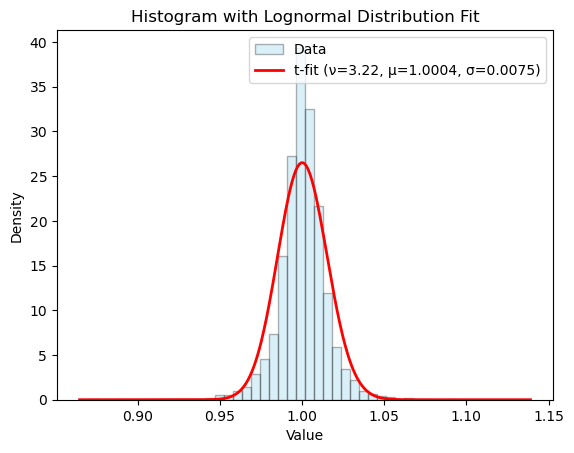

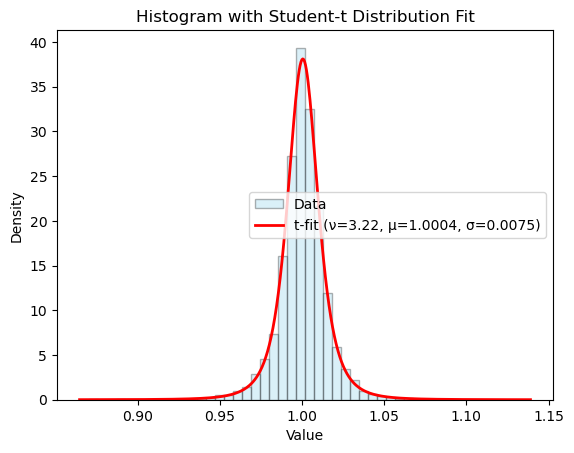

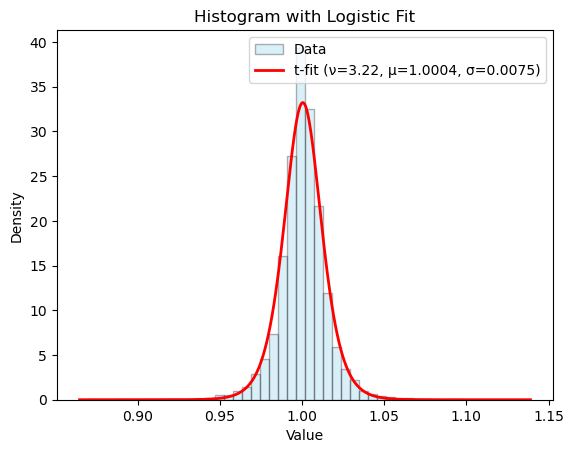

In [79]:
# Plot histogram of data
plt.hist(data, bins=50, density=True, alpha=0.3, color='skyblue', edgecolor='black', label='Data')

# Create smooth x-axis
x = np.linspace(min(data), max(data), 500)
pdf = stats.norm.pdf(x, loc=mu_norm, scale=sigma_norm)
# Overlay t-distribution curve
plt.plot(x, pdf, 'r-', linewidth=2, label=f"t-fit (ν={df:.2f}, μ={loc:.4f}, σ={scale:.4f})")

plt.title("Histogram with normal distribution Fit")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()
##########################################################################################################################
# Plot histogram of data
plt.hist(data, bins=50, density=True, alpha=0.3, color='skyblue', edgecolor='black', label='Data')

# Create smooth x-axis
x = np.linspace(min(data), max(data), 500)

# Evaluate fitted PDF
pdf =  stats.lognorm.pdf(x, shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)

# Overlay t-distribution curve
plt.plot(x, pdf, 'r-', linewidth=2, label=f"t-fit (ν={df:.2f}, μ={loc:.4f}, σ={scale:.4f})")

plt.title("Histogram with Lognormal Distribution Fit")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

##########################################################################################################################
plt.hist(data, bins=50, density=True, alpha=0.3, color='skyblue', edgecolor='black', label='Data')

# Create smooth x-axis
x = np.linspace(min(data), max(data), 500)

# Evaluate fitted PDF
pdf = t.pdf(x, df_t, loc=loc_t, scale=scale_t)

# Overlay t-distribution curve
plt.plot(x, pdf, 'r-', linewidth=2, label=f"t-fit (ν={df:.2f}, μ={loc:.4f}, σ={scale:.4f})")

plt.title("Histogram with Student-t Distribution Fit")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

##########################################################################################################################
# Plot histogram of data
plt.hist(data, bins=50, density=True, alpha=0.3, color='skyblue', edgecolor='black', label='Data')

# Create smooth x-axis
x = np.linspace(min(data), max(data), 500)

# Evaluate fitted PDF
pdf  = stats.logistic.pdf(x, loc=loc_logistic, scale=scale_logistic)

# Overlay t-distribution curve
plt.plot(x, pdf, 'r-', linewidth=2, label=f"t-fit (ν={df:.2f}, μ={loc:.4f}, σ={scale:.4f})")

plt.title("Histogram with Logistic Fit")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

In [96]:
q = t.ppf(0.01, df_t, loc=loc_t, scale=scale_t)-1
var_99_paramatric = q*princeple
print('Paramatric method 99% Var = :', var_99_paramatric)

Paramatric method 99% Var = : -4129.2176800247


#####
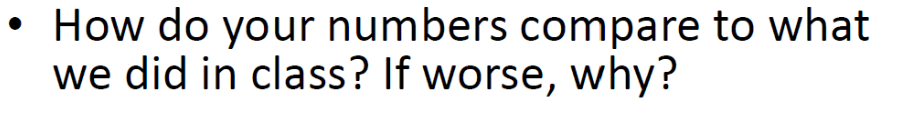
Answer: My answer is not same as class return, which is because in class the task is to calculate VaR for KO and Spread.